**Author:** Tiffany Ewa Ajayi  

### Abstract
Do Bay Area Earthquakes Care If You're Asleep?
Using USGS seismic catalog data for the San Francisco Bay Area (2003–2026, M ≥ 3.3, n = 335), this study examines whether earthquake occurrence and magnitude vary between human sleep (23:00–07:00) and awake (07:00–23:00) hours. Earthquakes occurred roughly twice as often during awake hours (n = 230) than sleep hours (n = 105), consistent with the longer awake window. Notably, the largest recorded event — the M6.02 South Napa earthquake (August 24, 2014, 03:20 local time) — struck during sleep hours, while the maximum awake-period magnitude was M5.45. Of the 50 largest events, 33 occurred during awake hours and 17 during sleep. January showed the highest monthly event count, and August the highest peak magnitude. Mean magnitude remained stable across all years (~3.5–3.8), with 2014 as a clear outlier in both max and mean magnitude, driven by the Napa mainshock and its aftershock sequence.



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
standard_url = 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&orderby=magnitude'

eq0 = (
    standard_url
    + "&starttime=2003-05-05T00:00:00"
    + "&endtime=2026-03-05T12:00:00"
    + "&minmagnitude=3.3"
    + "&minlatitude=36.0&maxlatitude=38.5"
    + "&minlongitude=-123.0&maxlongitude=-121.0"
    + "&limit=20000"
)
eq = pd.read_csv(eq0)

In [ ]:
eq.head()

In [ ]:
# categorize by sleep and awake. sleep = 23:00-07:00 og awake = 07:01-22:59
# make histogram or a plot. one bin for sleep and one bin for awake. 
# what is the largest magnitude for sleep, what is the larges magnitude for awake?
# for the top 50 largest eq, did it happen in sleep or awake time? plot map on where (mabye just top 20)
# for the top 50 lowest eq, did it happen in sleep or awake time? plot map on where (mabye just top 20)
# categorise the events by months 
# what year did the higest max magnitude happen, and what month was it?
# what year had the higest magnitude average, any correlation to the months? 
# would been cool to see eq swarms correlation with high magnitude eq. 
# 

In [ ]:
eq['time'] = pd.to_datetime(eq['time'])
eq['time_local'] = eq['time'].dt.tz_convert('America/Los_Angeles')  
eq['hour'] = eq['time_local'].dt.hour
eq['month'] = eq['time_local'].dt.month
eq['year'] = eq['time_local'].dt.year

print(f"{len(eq)} earthquakes")

Loaded 335 earthquakes


In [15]:
# Sleep vs Awake
# Sleep: 23:00–06:59  |  Awake: 07:00–22:59

def classify_time(hour):
    return 'Sleep' if (hour >= 23 or hour < 7) else 'Awake'


eq['period'] = eq['hour'].apply(classify_time)

counts = eq['period'].value_counts()
print(counts)


print("\nMax magnitude:")
print(eq.groupby('period')['mag'].max())

period
Awake    230
Sleep    105
Name: count, dtype: int64

Max magnitude:
period
Awake    5.45
Sleep    6.02
Name: mag, dtype: float64


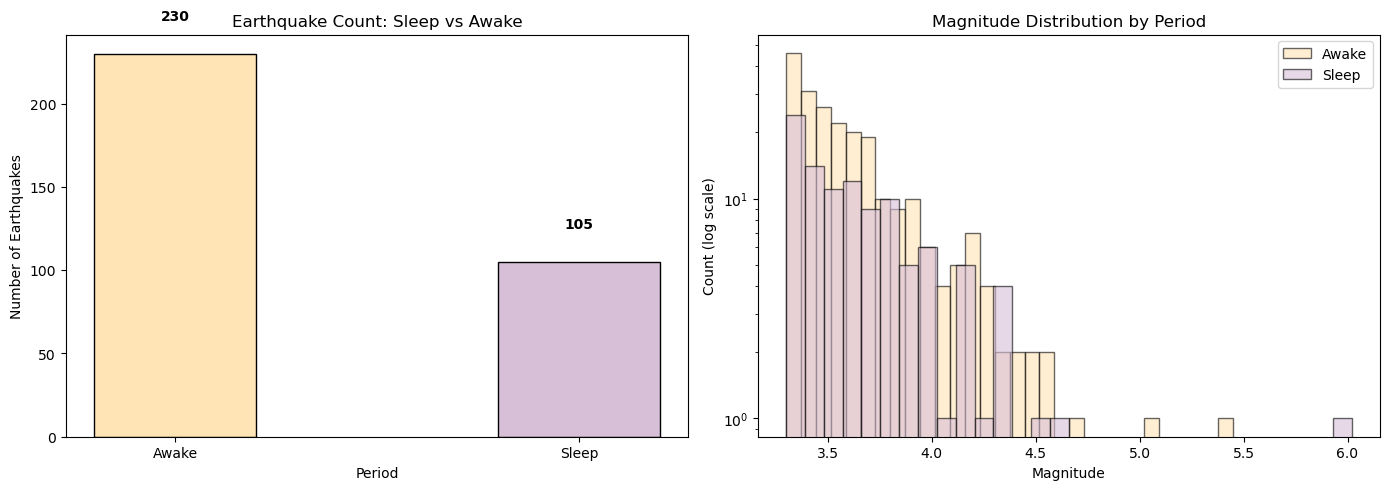

In [18]:
# Plot Sleep vs Awake

fig, axes = plt.subplots(1, 2, figsize=(14, 5))



axes[0].bar(counts.index, counts.values, color=['moccasin', 'thistle'], edgecolor='k', width=0.4)
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Number of Earthquakes')
axes[0].set_title('Earthquake Count: Sleep vs Awake')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold')


for label, color in zip(['Awake', 'Sleep'], ['moccasin','thistle']):
    axes[1].hist(eq[eq['period'] == label]['mag'], bins=30, alpha=0.6,
                 label=label, color=color, edgecolor='k')
    
axes[1].set_yscale('log')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Magnitude Distribution by Period')
axes[1].legend()
    


plt.tight_layout()
plt.show()


Top 50 largest — Sleep vs Awake:
period
Awake    33
Sleep    17
Name: count, dtype: int64


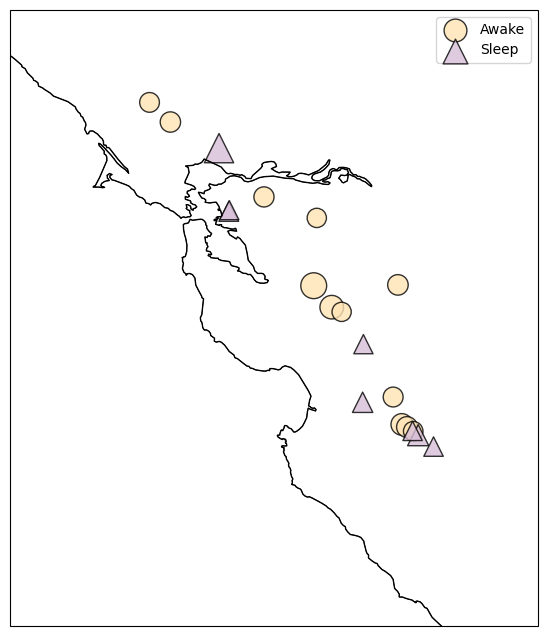

In [24]:
# the distubution of top 50 largest eq, and ploting top 20 on the map 


top50_large = eq.nlargest(50, 'mag')
top20_large = eq.nlargest(20, 'mag')

print("Top 50 largest — Sleep vs Awake:")
print(top50_large['period'].value_counts())


fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-123.5, -120.5, 35.5, 39.0])
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.STATES, linewidth=0.5)

            
for period, color, marker in zip(['Awake', 'Sleep'], ['moccasin', 'thistle'], ['o', '^']):
    subset = top20_large[top20_large['period'] == period]
    ax.scatter(subset['longitude'], subset['latitude'],
               s=subset['mag'] ** 2.5 * 5, c=color, marker=marker,
               transform=ccrs.PlateCarree(), label=f'{period}', alpha=0.8, edgecolor='k'
    )

plt.legend()
plt.show()

Top 50 smallest — Sleep vs Awake:
period
Awake    35
Sleep    15
Name: count, dtype: int64


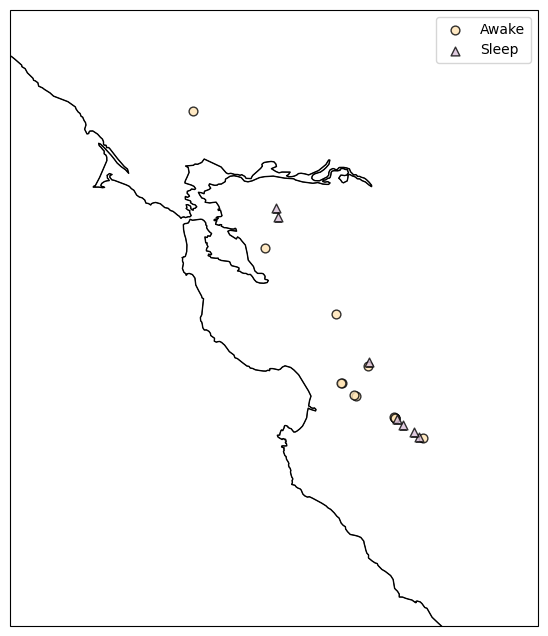

In [27]:
# the distubution of top 50 smallest eq, and ploting top 20 on the map 
top50_small = eq.nsmallest(50, 'mag')
top20_small = eq.nsmallest(20, 'mag')

print("Top 50 smallest — Sleep vs Awake:")
print(top50_small['period'].value_counts())

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-123.5, -120.5, 35.5, 39.0])
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.STATES, linewidth=0.5)

for period, color, marker in zip(['Awake', 'Sleep'], ['moccasin', 'thistle'], ['o', '^']):
    subset = top20_small[top20_small['period'] == period]
    ax.scatter(subset['longitude'], subset['latitude'],
               s=40, c=color, marker=marker,
               transform=ccrs.PlateCarree(), label=f'{period}', alpha=0.8, edgecolor='k')
plt.legend()
plt.show()

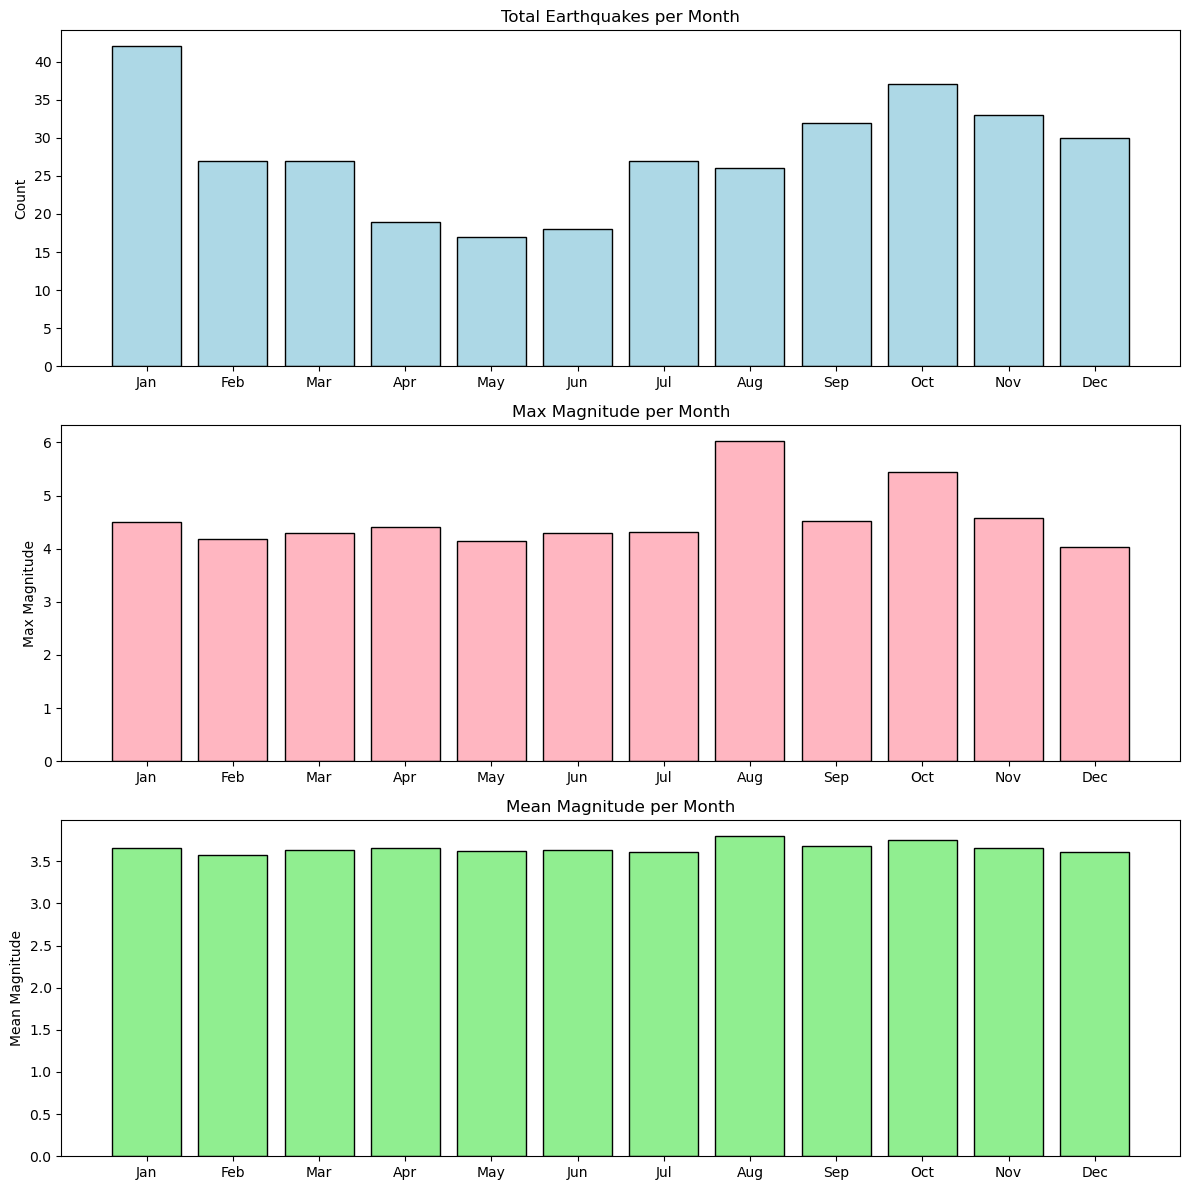

In [29]:
# lookig at the months of the years 

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly = eq.groupby('month').agg(
    count=('mag', 'count'),
    max_mag=('mag', 'max'),
    mean_mag=('mag', 'mean')
).reset_index()
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])


fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].bar(monthly['month_name'], monthly['count'], color='lightblue', edgecolor='k')
axes[0].set_title('Total Earthquakes per Month')
axes[0].set_ylabel('Count')

axes[1].bar(monthly['month_name'], monthly['max_mag'], color='lightpink', edgecolor='k')
axes[1].set_title('Max Magnitude per Month')
axes[1].set_ylabel('Max Magnitude')

axes[2].bar(monthly['month_name'], monthly['mean_mag'], color='lightgreen', edgecolor='k')
axes[2].set_title('Mean Magnitude per Month')
axes[2].set_ylabel('Mean Magnitude')

plt.tight_layout()
plt.show()

Highest max magnitude: Year 2014, M6.02
Highest mean magnitude: Year 2014, mean M3.81

Global max event: M6.02 on 2014-08-24 03:20:44.070000-07:00 (Aug)


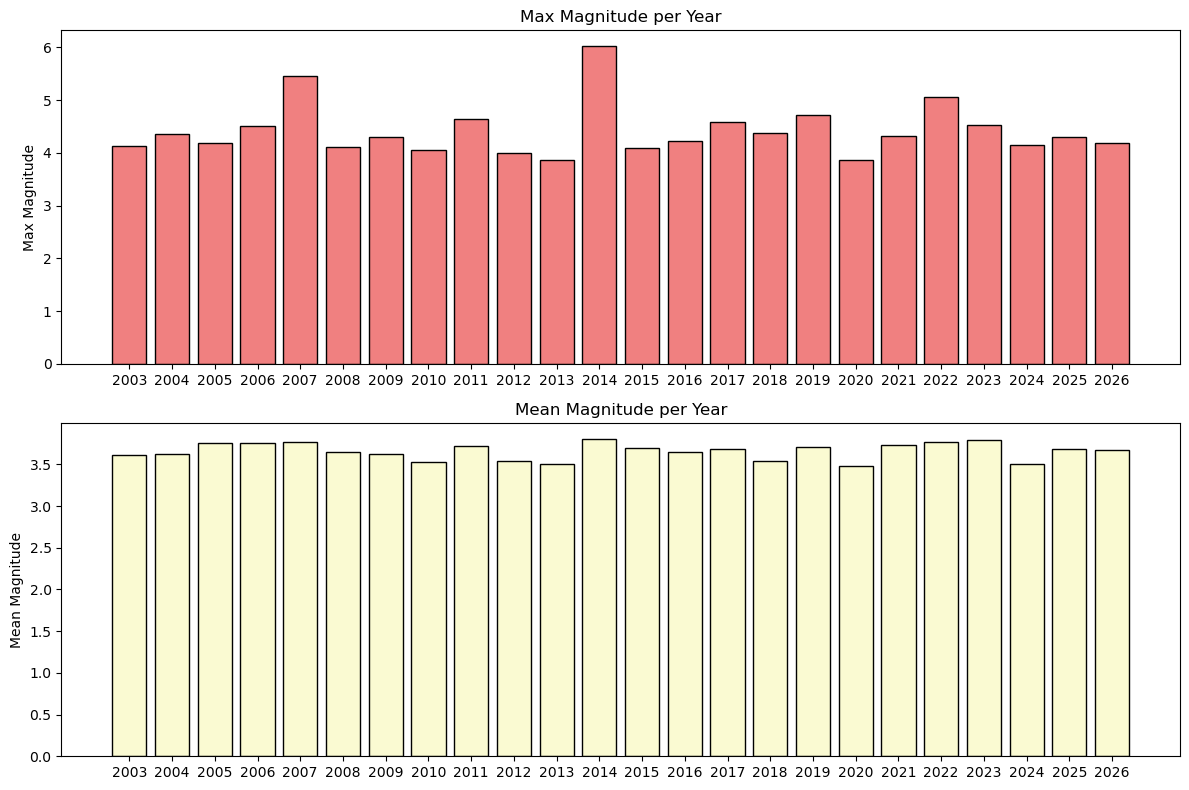

In [31]:
# year with higest max and mean magnitude
yearly = eq.groupby('year').agg(
    count=('mag', 'count'),
    max_mag=('mag', 'max'),
    mean_mag=('mag', 'mean')
).reset_index()

best_max_year = yearly.loc[yearly['max_mag'].idxmax()]
best_mean_year = yearly.loc[yearly['mean_mag'].idxmax()]

print(f"Highest max magnitude: Year {int(best_max_year['year'])}, M{best_max_year['max_mag']:.2f}")
print(f"Highest mean magnitude: Year {int(best_mean_year['year'])}, mean M{best_mean_year['mean_mag']:.2f}")

# Check what month the global max occurred
global_max = eq.loc[eq['mag'].idxmax()]
print(f"\nGlobal max event: M{global_max['mag']} on {global_max['time_local']} ({month_names[global_max['month']-1]})")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].bar(yearly['year'], yearly['max_mag'], color='lightcoral', edgecolor='k')
axes[0].set_title('Max Magnitude per Year')
axes[0].set_ylabel('Max Magnitude')
axes[0].set_xticks(yearly['year'])

axes[1].bar(yearly['year'], yearly['mean_mag'], color='lightgoldenrodyellow', edgecolor='k')
axes[1].set_title('Mean Magnitude per Year')
axes[1].set_ylabel('Mean Magnitude')
axes[1].set_xticks(yearly['year'])

plt.tight_layout()
plt.show()